# Diabetes Risk Prediction — Feature Engineering & Baseline Model

**Goal:** Prepare the data for modeling and train an interpretable baseline model.

Sections:
1. Load cleaned data
2. Train/test split
3. Feature engineering (encoding, scaling)
4. Handle class imbalance
5. Baseline model: Logistic Regression
6. Evaluation (precision, recall, F1, ROC-AUC)
7. Key takeaways

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

## 1. Load Cleaned Data

Re-load the data and re-apply the cleaning steps from notebook 01 (drop duplicates).
If you saved a cleaned CSV from notebook 01, load that instead.

In [2]:
from ucimlrepo import fetch_ucirepo

cdc_diabetes = fetch_ucirepo(id=891)
X_raw = cdc_diabetes.data.features
y_raw = cdc_diabetes.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
df = df.drop_duplicates().reset_index(drop=True)

target_col = 'Diabetes_binary'
print(df.shape)
df.head()

(229474, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


## 2. Train/Test Split

Split BEFORE any scaling or resampling to avoid data leakage. Use stratified splitting
so both sets preserve the class imbalance ratio.

In [3]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('\nTrain class balance:')
print(y_train.value_counts(normalize=True))
print('\nTest class balance:')
print(y_test.value_counts(normalize=True))

Train shape: (183579, 21)
Test shape: (45895, 21)

Train class balance:
Diabetes_binary
0    0.847052
1    0.152948
Name: proportion, dtype: float64

Test class balance:
Diabetes_binary
0    0.847064
1    0.152936
Name: proportion, dtype: float64


## 3. Feature Engineering

Most features in this dataset are already binary (0/1) or ordinal, which is convenient.
The main things to handle:
- Scale continuous features (BMI, MentHlth, PhysHlth) for logistic regression
- Optionally create derived features (e.g. BMI categories)

Fit the scaler on TRAIN only, then apply to both train and test — never fit on test data.

In [4]:
# Identify continuous features that benefit from scaling
continuous_features = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
continuous_features = [c for c in continuous_features if c in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

X_train_scaled.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
154325,1,0,1,-0.395435,1,0,0,1,0,1,...,0,0,2,-0.455262,-0.517047,0,1,-0.350440,0.020709,0.529942
136550,1,1,1,0.786628,0,0,0,1,0,1,...,1,0,3,-0.455262,-0.517047,0,0,0.620283,-0.986375,-1.381726
21711,0,1,1,-0.690951,0,0,0,1,1,1,...,1,0,2,-0.455262,-0.517047,0,0,0.620283,1.027793,1.007859
210091,0,1,1,-0.986467,0,0,0,1,1,1,...,1,0,2,-0.455262,-0.517047,0,0,1.591006,0.020709,-0.425892
138820,1,0,1,0.195596,0,0,0,1,1,1,...,1,0,4,-0.455262,0.698722,1,0,-0.350440,-0.986375,-0.425892


In [7]:
# Optional: derived feature example — BMI category
def bmi_category(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    else:
        return 'obese'



## 4. Handle Class Imbalance

This dataset is imbalanced. Two common approaches:
- **Class weighting** (simpler, no synthetic data): pass `class_weight='balanced'` to the model
- **Resampling** (SMOTE, undersampling): rebalances the training data directly

We'll start with class weighting for the baseline — it's simpler and a fair first attempt.

In [8]:
# Check the imbalance ratio
ratio = y_train.value_counts(normalize=True)
print(f"Class imbalance ratio (train): {ratio[0]:.1%} negative vs {ratio[1]:.1%} positive")

Class imbalance ratio (train): 84.7% negative vs 15.3% positive


## 5. Baseline Model: Logistic Regression

In [9]:
baseline_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

baseline_model.fit(X_train_scaled, y_train)

y_pred = baseline_model.predict(X_test_scaled)
y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

## 6. Evaluation

Remember: accuracy is misleading here. Focus on precision, recall, F1, and ROC-AUC.

In [10]:
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes/Pre']))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC: {roc_auc:.3f}')

              precision    recall  f1-score   support

 No Diabetes       0.94      0.71      0.81     38876
Diabetes/Pre       0.32      0.76      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.73      0.63     45895
weighted avg       0.85      0.71      0.75     45895

ROC-AUC: 0.811


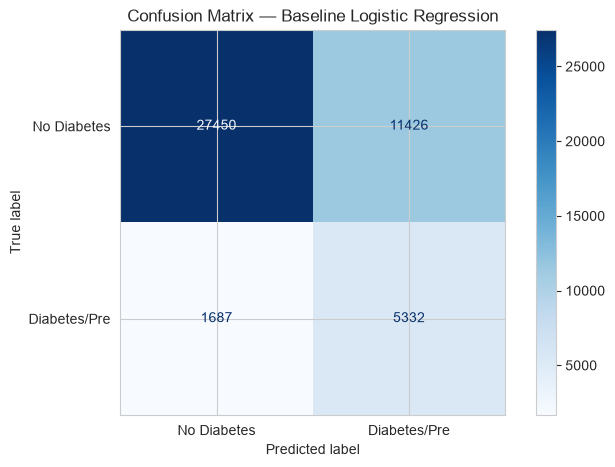

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes/Pre'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Baseline Logistic Regression')
plt.show()

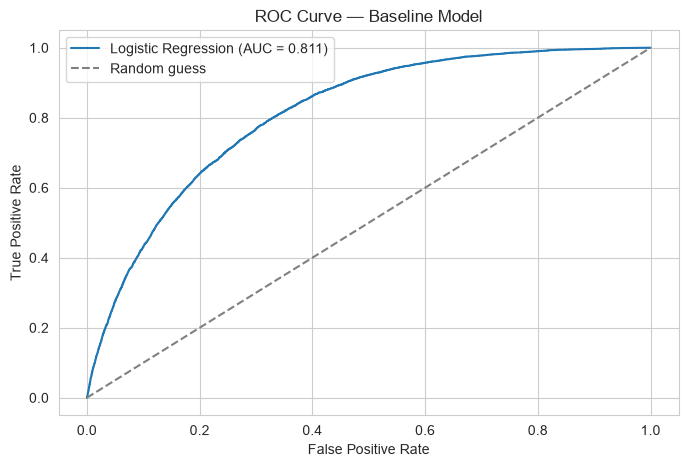

In [12]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline Model')
plt.legend()
plt.show()

                 feature  coefficient
2              CholCheck     1.313651
10     HvyAlcoholConsump    -0.789656
0                 HighBP     0.714378
1               HighChol     0.565311
13               GenHlth     0.538601
3                    BMI     0.468991
18                   Age     0.443092
17                   Sex     0.286190
6   HeartDiseaseorAttack     0.235426
5                 Stroke     0.161234


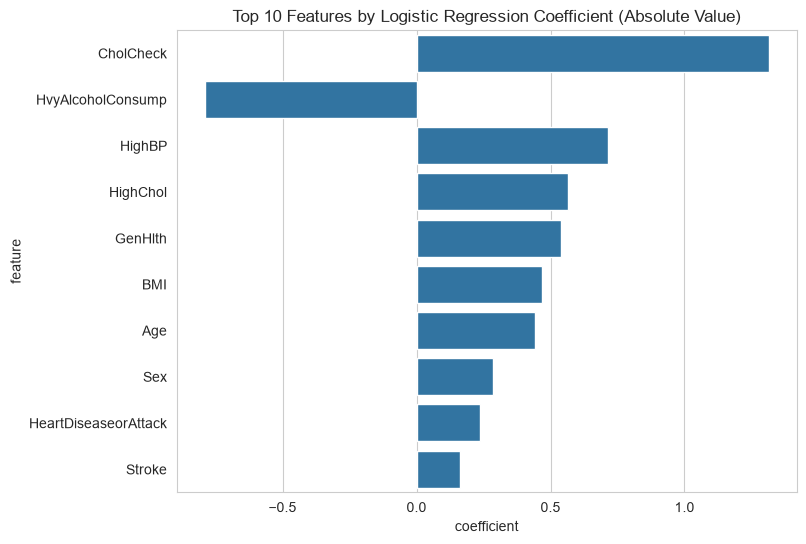

In [13]:
# Which features matter most in this baseline model?
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': baseline_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df.head(10))

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df.head(10), x='coefficient', y='feature')
plt.title('Top 10 Features by Logistic Regression Coefficient (Absolute Value)')
plt.show()